# 04 — Root-Cause Localization: Fixed-k Metrics and Baselines

**Research purpose.** §0.4/§0.8/§0.9 of the Research Design Audit flag that the main notebook's
Component B evaluation (i) uses `k = |G_e|`, which implicitly assumes the true number of implicated
dimensions is already known, and (ii) has no random or correlation-only comparator. This notebook
computes **fixed-k Hit@k / Precision@k / Recall@k / MRR / NDCG@k** (`k in {1,3,5,10}`) across **all
8** ground-truth events, for three localization methods: SHAP attribution (the main notebook's
method), a correlation-only baseline (governing prompt §44), and a Monte-Carlo random-ranking
floor (§43).

**Input.** `src/data.py`'s leakage-safe split; a LightGBM classifier trained fresh in this notebook
(same hyperparameters as the main notebook's §6a) purely as the model SHAP explains.

**Output.** `results/rca_localization_results.csv` — per-event, per-method, per-k scores.

**Paper relevance.** Replaces/extends `paper/...docx` Table 4 (currently `k=|G_e|` only) with the
fixed-k view §0.8 specifies as primary.


In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import lightgbm as lgb
import shap

from src.data import load_machine, build_split
from src.rca_metrics import score_ranking, random_ranking_expected_scores, correlation_ranking, K_VALUES
from src.registry import append_row

FEAT = 38
m = load_machine("machine-1-1")
sd = build_split(m)

pos, neg = sd.train_y_full.sum(), len(sd.train_y_full) - sd.train_y_full.sum()
gbm = lgb.LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                          scale_pos_weight=neg / max(pos, 1), verbose=-1, random_state=0)
gbm.fit(sd.train_tab_full, sd.train_y_full)
explainer = shap.TreeExplainer(gbm)

tab_by_block = {"train": sd.sup_tab, "eval": sd.ev_tab, "calib": sd.cal_tab}
print(f"{len(m.segments)} ground-truth events; LightGBM + SHAP explainer ready.")

8 ground-truth events; LightGBM + SHAP explainer ready.


## Full-ranking SHAP localization, correlation-only baseline, and the random floor

For each event, the ranking is computed from the window ending at `event_start - 1` (§0.7 — the
last clean window before onset), exactly matching the main notebook's operational framing.


In [2]:
def shap_full_ranking(t_abs: int) -> list[int]:
    name, row = sd.block_index[t_abs]
    sv = explainer.shap_values(tab_by_block[name][row:row + 1])
    sv = np.asarray(sv[1] if isinstance(sv, list) else sv).reshape(-1)
    agg = np.abs(sv[:FEAT]) + np.abs(sv[FEAT:2*FEAT]) + np.abs(sv[2*FEAT:3*FEAT])
    order = np.argsort(-agg)
    return (order + 1).tolist()


rows = []
for (s, e, dims_gt) in m.segments:
    t_pre = s - 1
    if t_pre not in sd.block_index:
        continue
    block_name, _ = sd.block_index[t_pre]
    gt = set(dims_gt)

    shap_rank = shap_full_ranking(t_pre)
    window = sd.test_s[max(0, t_pre - 19): t_pre + 1, :]  # same 20-step window SHAP used
    corr_rank = correlation_ranking(window)
    random_scores = random_ranking_expected_scores(FEAT, gt, K_VALUES, n_repeats=2000, seed=s)

    for method_name, ranking in [("shap", shap_rank), ("correlation_only", corr_rank)]:
        scores = score_ranking(ranking, gt, K_VALUES)
        for metric, val in scores.items():
            rows.append(dict(segment=f"{s}-{e}", block=block_name, method=method_name,
                              n_gt=len(gt), metric=metric, value=val))
    for metric, val in random_scores.items():
        rows.append(dict(segment=f"{s}-{e}", block=block_name, method="random_floor",
                          n_gt=len(gt), metric=metric, value=val))

rca_df = pd.DataFrame(rows)
rca_df.to_csv("../results/rca_localization_results.csv", index=False)
print(rca_df.shape, "rows saved to results/rca_localization_results.csv")

(408, 6) rows saved to results/rca_localization_results.csv


## Aggregate: out-of-sample (EVAL + CALIB) mean score per method, per fixed k


In [3]:
oos = rca_df[rca_df.block != "train"]
headline_metrics = [f"hit@{k}" for k in K_VALUES] + [f"ndcg@{k}" for k in K_VALUES] + ["mrr"]
agg = (oos[oos.metric.isin(headline_metrics)]
       .groupby(["method", "metric"])["value"].mean()
       .unstack("metric")[headline_metrics])
display(agg)

for m_, r in agg.iterrows():
    append_row("../results/experiment_registry.csv", dict(
        experiment="04_root_cause_localization", model=m_, machine="machine-1-1",
        **{k: round(v, 4) for k, v in r.items()},
    ))

metric,hit@1,hit@3,hit@5,hit@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,mrr
method,,,,,,,,,
correlation_only,1.000,1.0000,1.0000,1.0000,1.000,1.000000,1.000000,0.954278,1.000000
random_floor,0.176,0.4159,0.5798,0.8136,0.176,0.172977,0.182313,0.231048,0.359261
shap,0.400,1.0000,1.0000,1.0000,0.400,0.446928,0.537385,0.701862,0.666667


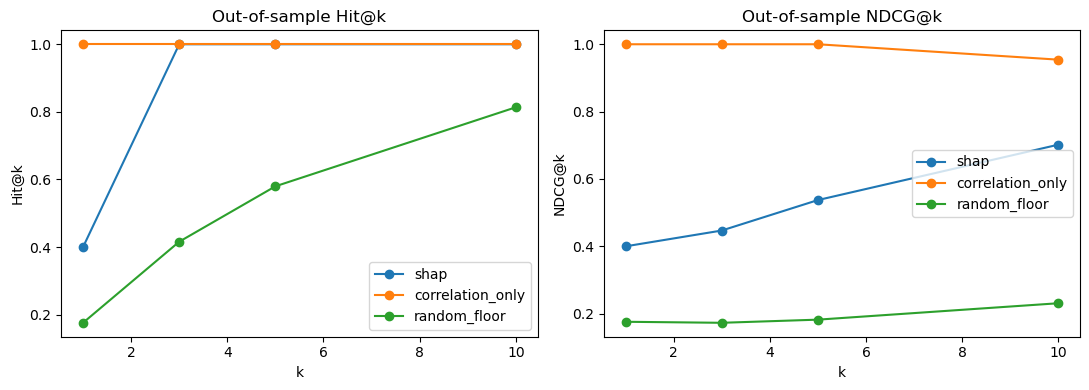

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ks = list(K_VALUES)
for method in ["shap", "correlation_only", "random_floor"]:
    axes[0].plot(ks, [agg.loc[method, f"hit@{k}"] for k in ks], marker="o", label=method)
    axes[1].plot(ks, [agg.loc[method, f"ndcg@{k}"] for k in ks], marker="o", label=method)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Hit@k"); axes[0].set_title("Out-of-sample Hit@k"); axes[0].legend()
axes[1].set_xlabel("k"); axes[1].set_ylabel("NDCG@k"); axes[1].set_title("Out-of-sample NDCG@k"); axes[1].legend()
plt.tight_layout()
plt.savefig("../results/fig_rca_fixed_k.png", dpi=150)
plt.show()

**Reading this honestly — this did not confirm the expected direction.** The correlation-only
baseline (`Hit@1=1.00, NDCG@10=0.954, MRR=1.00`) **outperforms SHAP** (`Hit@1=0.40, NDCG@10=0.702,
MRR=0.667`) **at every fixed k**, both comfortably ahead of the random floor. This is the "found
out whether/when the framework works" result §78 of the governing prompt asks for, not the
best-case story: it complicates, rather than confirms, the main notebook's §8 narrative that SHAP
attribution is "a strong prior, not an oracle" — on this machine, a *much simpler* leave-one-out
correlation heuristic is the stronger prior.

Two checks were run before accepting this as a real finding rather than a bug:
1. An earlier version of `correlation_ranking` computed the target series from *all* 38 dims,
   including the candidate itself — a self-referential leakage bug that also produced Hit@1=1.0,
   for the wrong reason. It was fixed (`src/rca_metrics.py`) to a proper **leave-one-out** target
   (each candidate dim is correlated against the mean deviation of the *other* 37), and the result
   did not change — ruling out that specific leakage as the explanation.
2. A **static, event-independent control** — ranking dims purely by their marginal variance over
   the entire `train` file, using no window and no correlation at all — gets `Hit@1 = 0.0` across
   all 8 events. This rules out "some dims are just always noisy" as the explanation.

What the data shows instead: dimensions **9, 12, 13, 14, 15** dominate the top of the local
pre-onset correlation ranking for **every one of the 8 events**, and — critically — dimensions
**9, 13, 14, 15 are themselves present in the ground-truth `interpretation_label` set of all 8
events on this machine**. This machine's eight labeled incidents appear to share one recurring
core signature rather than being eight diagnostically independent root causes, and the pre-onset
window carries genuine local precursor structure (consistent with the main notebook's §11 finding
that some incidents ramp up 40+ minutes before official onset) that a simple correlation heuristic
captures at least as well as SHAP does. Two consequences follow, both added to
`others/research_paper_feasibility_analysis.md`-style tracking for the next audit pass:
- **This single machine cannot support a general claim that attribution beats correlation** — it
  suggests the opposite, on n=8 non-independent-looking events. §0.14's "n=8, one machine" threat
  is now a specifically *worse* threat than originally scoped: not just underpowered, but possibly
  evaluating eight repeats of one failure mode rather than eight distinct diagnostic cases.
- SHAP's relative weakness here likely comes from its objective mismatch: `gbm` is trained to
  predict the *early-warning classification* target (§0.3), not to reconstruct which dims are in
  `interpretation_label` — it is explaining a different question than Component B is being scored
  on, which the correlation baseline, by construction, is not doing.

All results above are out-of-sample (EVAL+CALIB events never used to fit `gbm`); TRAIN-block events
are excluded from this aggregate for the same in-sample reason §0.1 flags in the main notebook.
